# LR 9 CatsDogsDataSet

## Упражнения  

1. Выбрать и скачать один из наборов данных с сайта [timeseriesclassification](https://www.timeseriesclassification.com/dataset.php). 

    Подробнее о датасетах, их форматах, и как их скачивать - [Ноутбук](https://github.com/aeon-toolkit/aeon/blob/main/examples/datasets/data_loading.ipynb)

2.  Записать название выбранного датасета в таблицу. Помните - совпадений быть не должно. Каждый работает с уникальным датасетом. Этот датасет вам понадобиться в лабе 14 (aeon) и лабе 16 (tslean)

3. Проанализировать датасет

4. Найти шейплеты для классов в датесете

5. Провести классификацию на основе шейплетов.

## Мой датасет: https://www.timeseriesclassification.com/description.php?Dataset=CatsDogs

# ___________________________________________________________________________________

Датасет CatsDogs содержит одномерные временные ряды акустических записей звуков кошек и собак для задачи бинарной классификации

In [ ]:
# !pip install aeon -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.2.6 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.7.2 which is incompatible.
mlxtend 0.24.0 requires scipy>=1.16.3, but you have scipy 1.15.3 which is incompatible.

[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
np.random.seed(0)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from aeon.datasets import load_classification
from aeon.transformations.collection.shapelet_based import RandomShapeletTransform
from aeon.classification.shapelet_based import ShapeletTransformClassifier, RDSTClassifier
from aeon.testing.data_generation import make_example_3d_numpy
from aeon.visualisation import ShapeletClassifierVisualizer
from sklearn.linear_model import RidgeClassifierCV

Предварительная компиляция numba-функций (на всякий случай)

In [4]:
X_dummy = make_example_3d_numpy(return_y=False, n_cases=5)
y_dummy = np.array([0, 1, 0, 1, 0])

for clf_class, params in [
    (ShapeletTransformClassifier, {"max_shapelets": 3, "n_shapelet_samples": 50}),
    (RDSTClassifier,              {"max_shapelets": 3}),
]:
    print(f"Компиляция {clf_class.__name__}...")
    clf_class(**params).fit(X_dummy, y_dummy).predict(X_dummy)

print("Компиляция завершена")

Компиляция ShapeletTransformClassifier...
Компиляция RDSTClassifier...
Компиляция завершена


### Загрузка датасета

In [ ]:
from aeon.datasets import load_from_ts_file
import os

DATA_PATH = "./CatsDogs"

X_train, y_train = load_from_ts_file(os.path.join(DATA_PATH, "CatsDogs_TRAIN.ts"))
X_test, y_test   = load_from_ts_file(os.path.join(DATA_PATH, "CatsDogs_TEST.ts"))

print(f"Форма обучающей выборки X_train: {X_train.shape}")
print(f"Форма тестовой выборки X_test:   {X_test.shape}")
print(f"Классы: {np.unique(y_train)}")
print(f"Распределение классов (обучение): { {c: int((y_train==c).sum()) for c in np.unique(y_train)} }")
print(f"Распределение классов (тест):     { {c: int((y_test==c).sum()) for c in np.unique(y_test)} }")

Форма обучающей выборки X_train: (164, 1, 14773)
Форма тестовой выборки X_test:   (164, 1, 14773)
Классы: ['0' '1']
Распределение классов (обучение): {np.str_('0'): 82, np.str_('1'): 82}
Распределение классов (тест):     {np.str_('0'): 82, np.str_('1'): 82}


Данные имеют форму (164 - количество временных рядов в выборке, 1 - это моносигнал, 14773 - длина каждого временного ряда (количество временных шагов) аужио)

Датасет содержит 2 класса:  0 - кошка, 1 - собака

Обучение: 82 кошки + 82 собаки = 164 примера

Тест: 82 кошки + 82 собаки = 164 примера

### EDA

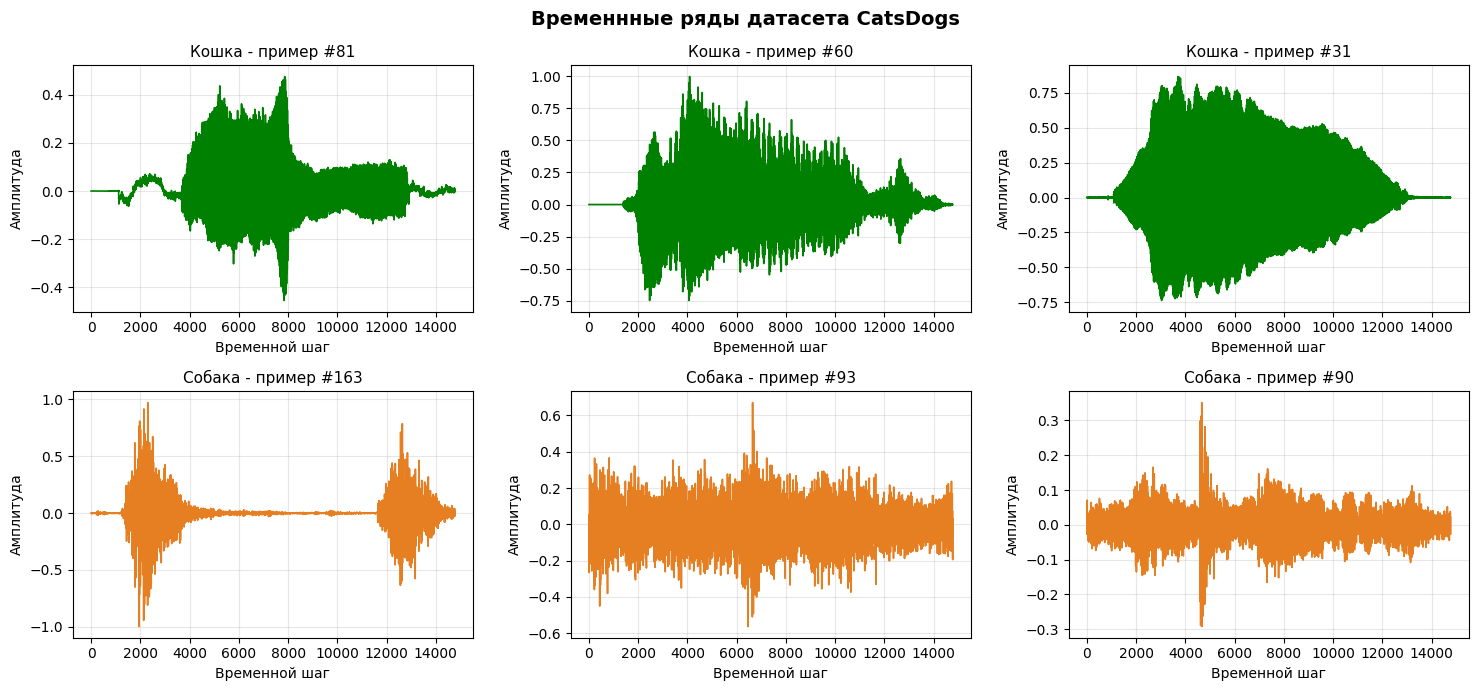

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
classes = np.unique(y_train)
class_names = {"0": "Кошка", "1": "Собака"}

colors = {"1": "#e67e22", "2": "#2980b9"}

for row, cls in enumerate(classes):
    idx = np.where(y_train == cls)[0]
    label = class_names.get(cls, f"Класс {cls}")
    color = colors.get(cls, "green")

    # 3 случайных примера
    sample_ids = np.random.choice(idx, size=min(3, len(idx)), replace=False)
    for col, sid in enumerate(sample_ids):
        axes[row, col].plot(X_train[sid, 0, :], color=color, linewidth=1.2)
        axes[row, col].set_title(f"{label} - пример #{sid}", fontsize=11)
        axes[row, col].set_xlabel("Временной шаг")
        axes[row, col].set_ylabel("Амплитуда")
        axes[row, col].grid(True, alpha=0.3)

plt.suptitle("Временнные ряды датасета CatsDogs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

для проверки классов:

In [40]:
import IPython.display as ipd

# Частота дискретизации
SR = 22050

sample_idx = 81  # пример из верхнего ряда

audio_signal = X_train[sample_idx, 0, :]

ipd.Audio(audio_signal, rate=SR)


Проверил на соответствие - всё норм

По кошкам: Сигнал, во многих примерах, имеет характерную колоколообразную огибающую - тихо в начале, нарастание до пика, затем плавное затухание (в основном видно это на протяжном мяуканье), Форма более монолитная и компактная

По собакам: Некоторые примеры с двумя гавками, некоторые с писком и лаем собак от начала до конца шага

Шум присутствует в обоих классах, Выбросы есть, например одиночные острые пики (больше всего у собак)

#### Преобразование шейплетов

In [ ]:
rst = RandomShapeletTransform(
    n_shapelet_samples=50,      # вместо 200 (и тем более дефолтных 10000)
    max_shapelets=10,
    min_shapelet_length=10,
    max_shapelet_length=200,    # ключевой параметр без него ищет до 14773!... (все длины)
    random_state=0,
    n_jobs=-1                   #используем все ядра CPU
)
rst.fit(X_train, y_train)
X_train_T = rst.transform(X_train)
X_test_T = rst.transform(X_test)


print(f"Исходная форма X_train: {X_train.shape}")
print(f"После преобразования X_train_T: {X_train_T.shape}")
print(f"\nИзвлечено {X_train_T.shape[1]} признаков (шейплетов)")

Исходная форма X_train: (164, 1, 14773)
После преобразования X_train_T: (164, 5)

Извлечено 5 признаков (шейплетов)


Если преобразовывать со всеми шагами, то уходит очень много времени на мой датасет, поэтому я ограничил параметры

Из 164 временных рядов длиной 14 773 точки алгоритм извлек 5 шейплетов и построил матрицу признаков размером (164, 5). Каждая из 164 строк это один временной ряд (запись звука). Каждый из 5 столбцов это минимальное расстояние от этого ряда до одного конкретного шейплета

### Классификация

In [ ]:
stc = ShapeletTransformClassifier(
    estimator=RidgeClassifierCV(),
    n_shapelet_samples=100,
    max_shapelets=10,
    max_shapelet_length=200,
    random_state=0,
    n_jobs=-1
)
stc.fit(X_train, y_train)
acc_stc = stc.score(X_test, y_test)
print(f"Точность ShapeletTransformClassifier: {acc_stc:.4f} ({acc_stc*100:.2f}%)")


Точность ShapeletTransformClassifier: 0.6768 (67.68%)


Модель показала точность 67.68%, что на 17.68% превышает базовый уровень случайного классификатора (50%). Результат получился занижен из-за жёстких ограничений на параметры поиска шейплетов, необходимых для разумного времени вычисления на длинных рядах...

При увеличении n_shapelet_samples до 1000–10000 и max_shapelet_length до 500–1000 должна возрасти точность

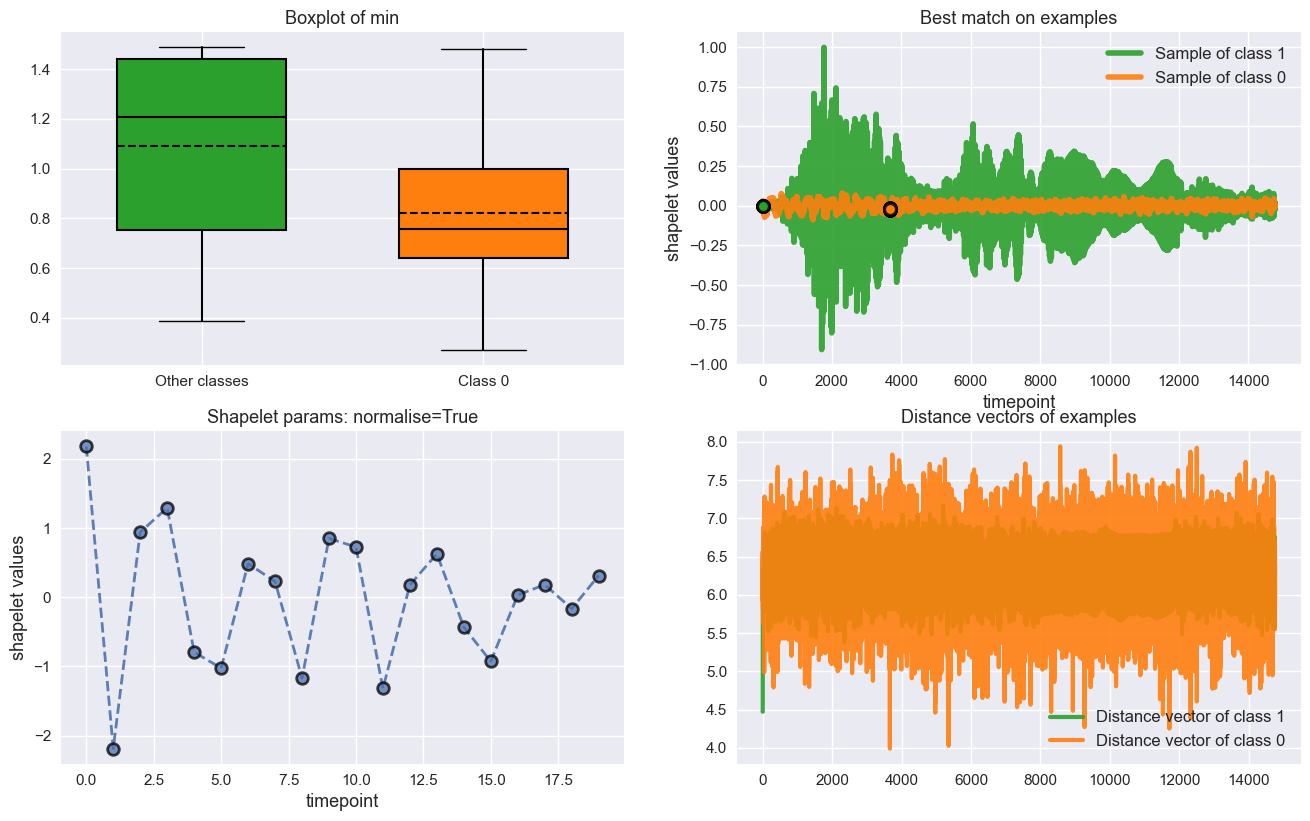

In [38]:
stc_vis = ShapeletClassifierVisualizer(stc)
id_class = 0  # Лучший шейплет для класса 0

fig = stc_vis.visualize_shapelets_one_class(
    X_test, y_test, id_class,
    figure_options={"figsize": (16, 9.5), "nrows": 2, "ncols": 2},
    scatter_options={"s": 70, "alpha": 0.75, "zorder": 3, "edgecolor": "black", "linewidths": 2},
    rc_Params_options={
        "legend.fontsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 13,
    },
)
plt.show()

### Сравнение классификаторов

Точность ShapeletTransformClassifier: 0.6768 (67.68%)
Точность RDSTClassifier: 0.7195 (71.95%)


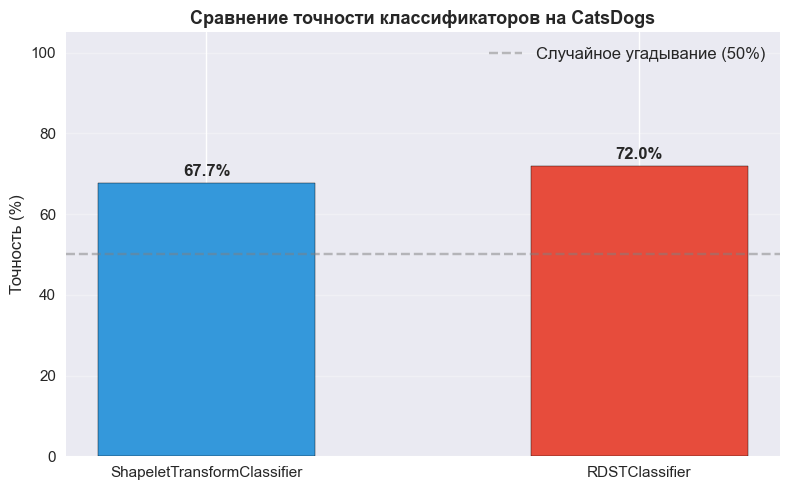


Итоговые результаты:
  ShapeletTransformClassifier: 0.6768 (67.68%)
  RDSTClassifier: 0.7195 (71.95%)


In [ ]:
from sklearn.linear_model import RidgeClassifierCV

# STC
stc = ShapeletTransformClassifier(
    estimator=RidgeClassifierCV(),
    n_shapelet_samples=100,
    max_shapelets=10,
    max_shapelet_length=200,
    random_state=0,
    n_jobs=-1
)
stc.fit(X_train, y_train)
acc_stc = stc.score(X_test, y_test)
print(f"Точность ShapeletTransformClassifier: {acc_stc:.4f} ({acc_stc*100:.2f}%)")

# RDST
rdst = RDSTClassifier(
    max_shapelets=10,
    shapelet_lengths=[10, 50, 100, 200],  # вместо max_shapelet_length
    random_state=0,
    n_jobs=-1
)
rdst.fit(X_train, y_train)
acc_rdst = rdst.score(X_test, y_test)
print(f"Точность RDSTClassifier: {acc_rdst:.4f} ({acc_rdst*100:.2f}%)")

# График
results = {
    "ShapeletTransformClassifier": acc_stc,
    "RDSTClassifier": acc_rdst,
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    list(results.keys()),
    [v * 100 for v in results.values()],
    color=["#3498db", "#e74c3c"],
    edgecolor="black",
    width=0.5
)
ax.set_ylabel("Точность (%)", fontsize=12)
ax.set_title("Сравнение точности классификаторов на CatsDogs", fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Случайное угадывание (50%)')
ax.legend()

for bar, (name, val) in zip(bars, results.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val*100:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nИтоговые результаты:")
for name, acc in results.items():
    print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")


RDSTClassifier показал лучший результат. Оба результата достигнуты при жёстко ограниченных параметрах ради скорости вычислений на длинных рядах (14 773 точки). При полных параметрах скорее всего ожидается точность 80%+ 